In [ ]:
import pandas as pd

#=================================================
#Load data
data=pd.read_csv('/content/household_power_consumption.txt', delimiter=';', na_values='?',
                 parse_dates={'Date_Time': ['Date', 'Time']}, #instead of manually creating date_time col
                 index_col='Date_Time')
data.info()
display(data.head(10))
print(data['Sub_metering_3'].describe())
print(data.dtypes)
df=data.copy()

#split numerical and categorical features
numerical_feat=df.select_dtypes(include=["int64","float64"]).columns
categorical_feat=df.select_dtypes(include='object').columns

print("numerical features:",len(numerical_feat))
print("categorical features:",len(categorical_feat))

#creating index column date_time
#df['Date_Time']=df['Date']+ ' '+ df['Time']

#print(df['Date_Time'].head(5))
#df=df.drop(columns=['Date','Time'],axis=1)

#df=df.set_index('Date_Time')

print(df.head(5))

/tmp/ipykernel_2358/2030439276.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data=pd.read_csv('/content/household_power_consumption.txt', delimiter=';', na_values='?',


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


/tmp/ipykernel_2358/2030439276.py:5: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data=pd.read_csv('/content/household_power_consumption.txt', delimiter=';', na_values='?',


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Date_Time,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
2006-12-16 17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0
2006-12-16 17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0
2006-12-16 17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0
2006-12-16 17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0


count    2.049280e+06
mean     6.458447e+00
std      8.437154e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.700000e+01
max      3.100000e+01
Name: Sub_metering_3, dtype: float64
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object
numerical features: 7
categorical features: 0
                     Global_active_power  Global_reactive_power  Voltage  \
Date_Time                                                                  
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64
datetime64[ns]
True
0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2006-12-16 to 2010-11-26
Freq: D
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    1442 non-null   float64
 1   Global_reactive_power  1442 non-null   float64
 2   Voltage                1442 non-null   float64
 3   Global_intensity       1442 non-null   float64
 4   Sub_metering_1         1442 non-null   float64
 5   Sub_metering_2         1442 non-null   float6

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Date_Time,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


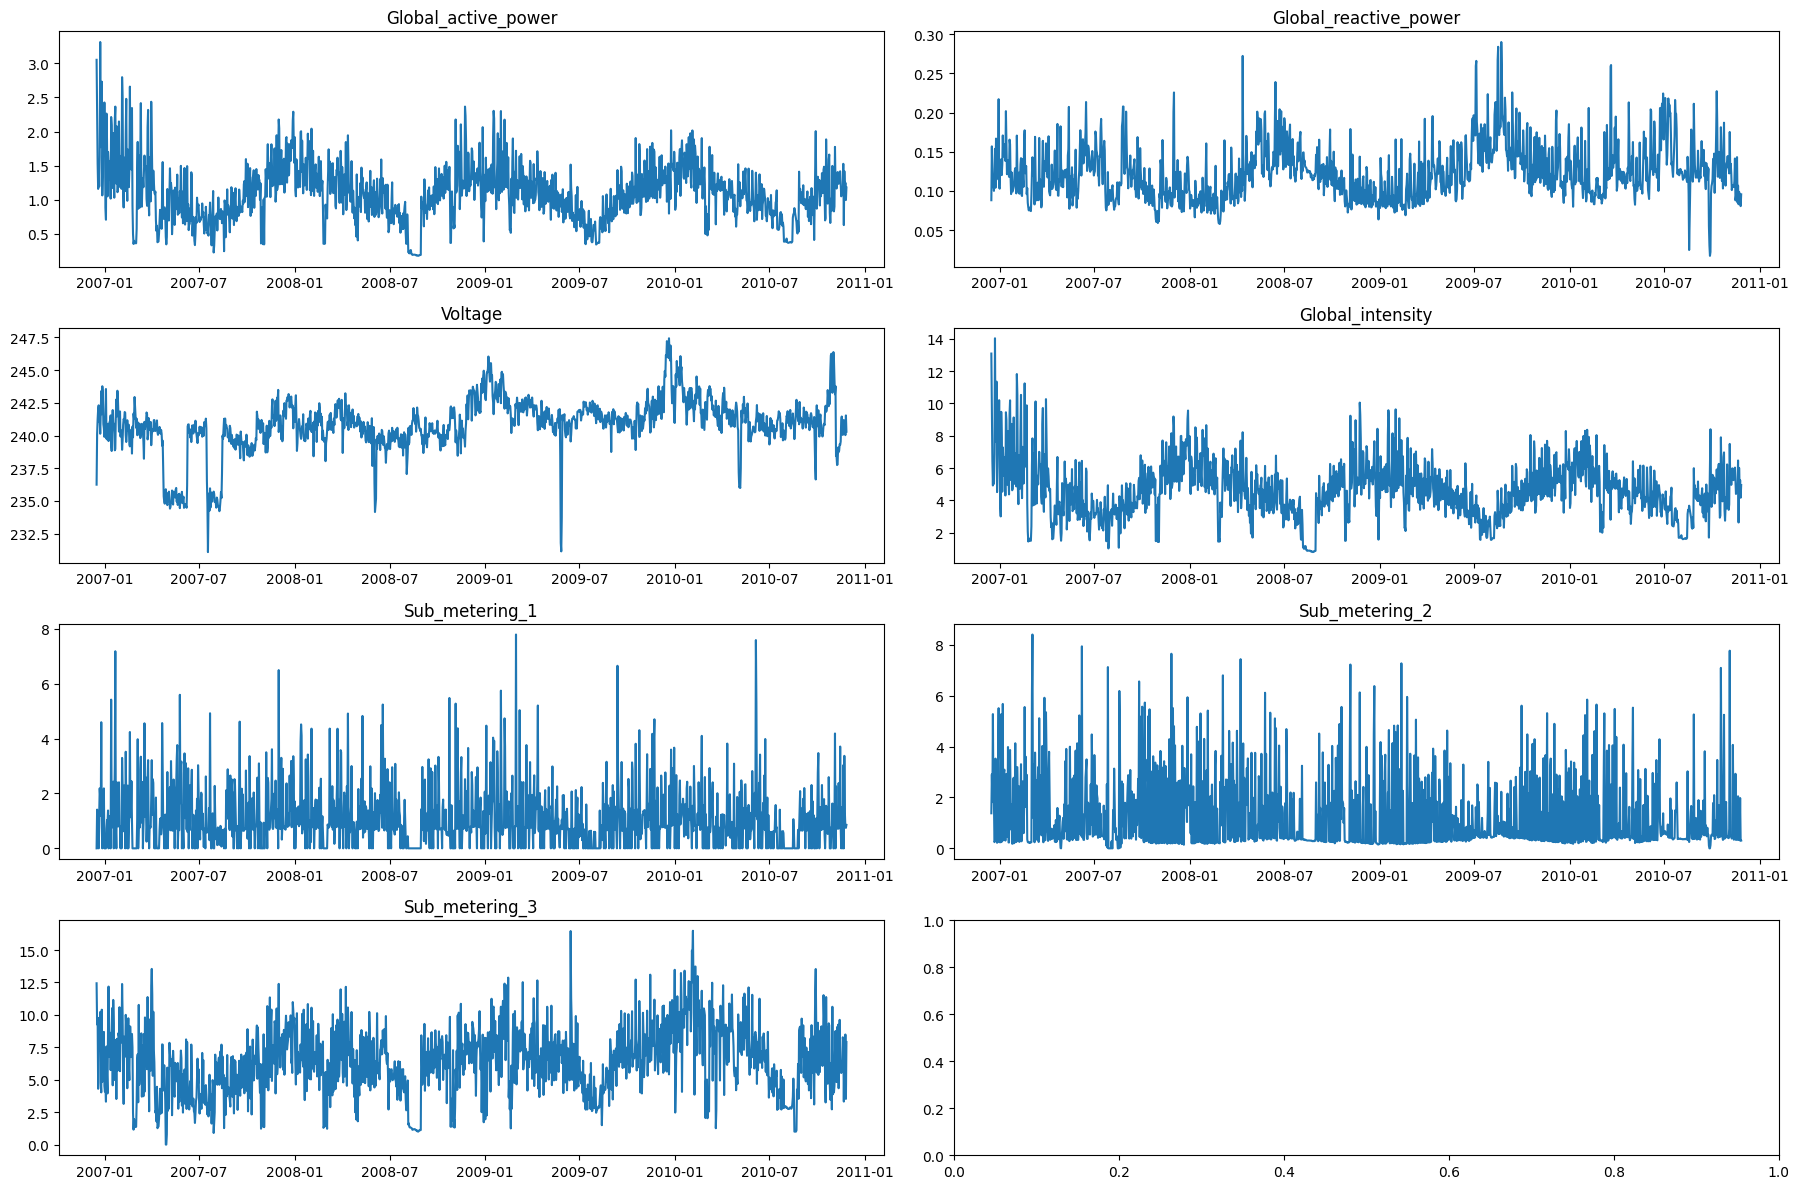

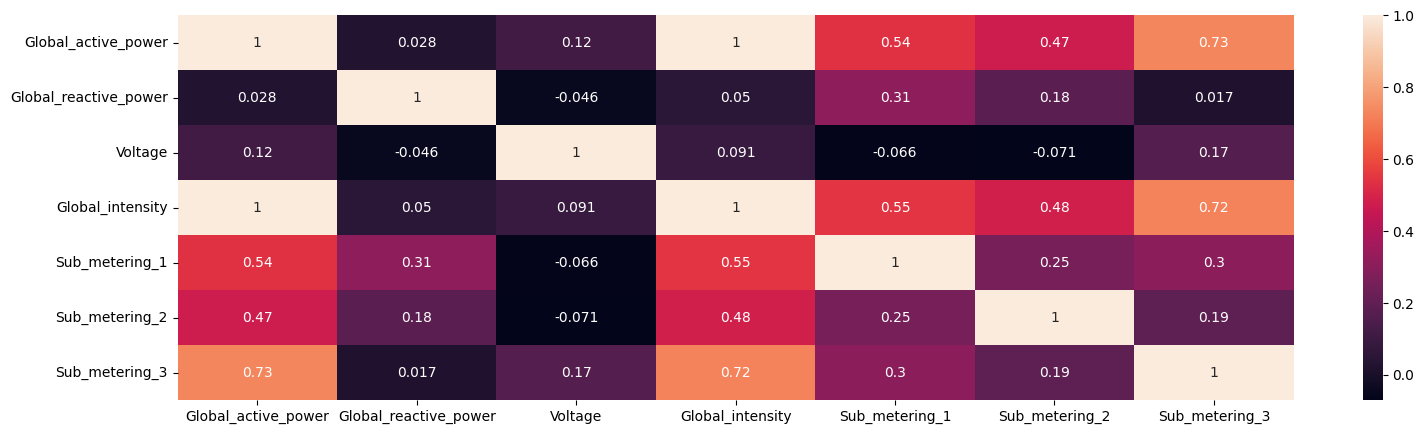

<Axes: xlabel='Date_Time'>

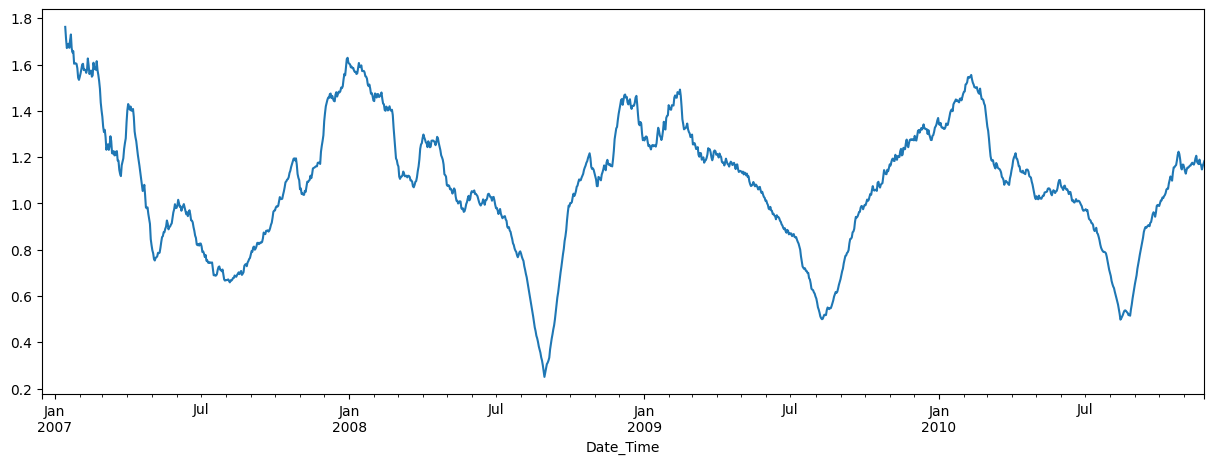

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

##Checking missing values
print(df.isnull().sum()) #25979
print(df.index.dtype)
print(df.index.is_monotonic_increasing) #True
df=df.sort_index()
print(df.index.duplicated().sum()) #0

#interpolate
#estimating missing values using nearby values. nearby in  terms of time index
df=df.interpolate(method='time')
print(df.isnull().sum()) #0


#resampling
#group all rows of each day and compute daily mean.
#shrinks dataset

df_daily=df.resample('D').mean()
df_daily.info()
display(df_daily.head(5))


#visulaizing all columns
fig,axe=plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(18,12)
)

axe=axe.flatten()# axe.shape was (4,2) after flatten it becomes (8,) to use axe[i]

for i,col in enumerate (df_daily.columns):

  axe[i].plot(df_daily[col])
  axe[i].set_title(col)

plt.tight_layout() #prevents overlapping
plt.show()


# Heatmap
plt.figure(figsize=(18,5))
sns.heatmap(df_daily.corr(),annot=True) #
plt.show()

#Correlation analysis showed that Global_intensity and Sub_metering_3 were strongly
#associated with Global_active_power, suggesting they may provide useful predictive
#information for forecasting models.


#Rolling mean
#For each day, compute average power over previous 30 days.
#This creates a:
#smoothed curve
#trend visualization

df_daily['Global_active_power'].rolling(30).mean().plot(figsize=(15,5)) #30 is the size of window

In [ ]:
#feature engineering
#Lag feature --> NOW the model has historical memory.
#            --> convert time-series problem into: supervised learning problem

df_daily = df_daily.copy()

target="Global_active_power" #the target’s own history is usually the strongest predictor.
df_daily["lag_1"]=df_daily[target].shift(1)
df_daily["lag_7"]=df_daily[target].shift(7) #value from 7 days ago, e.g Monday often resembles previous Monday.


#Rolling feature

df_daily["rolling_mean_7"]=df_daily[target].rolling(7).mean() #to have short-term trend
df_daily["rolling_std_7"]=df_daily[target].rolling(7).std() # recent variability: how much consumption changed during the last 7 days

#creating date features

df_daily["day_of_week"]=df_daily.index.day_of_week #weekdays vs weekends
df_daily["month"]=df_daily.index.month
print(df_daily.head(10))


df_daily=df_daily.dropna()
print(df_daily.isnull().sum())

            Global_active_power  Global_reactive_power     Voltage  \
Date_Time                                                            
2006-12-16             3.053475               0.088187  236.243763   
2006-12-17             2.354486               0.156949  240.087028   
2006-12-18             1.530435               0.112356  241.231694   
2006-12-19             1.157079               0.104821  241.999313   
2006-12-20             1.545658               0.111804  242.308062   
2006-12-21             1.192440               0.100115  241.041903   
2006-12-22             1.625929               0.129796  241.184549   
2006-12-23             3.314851               0.153799  240.136076   
2006-12-24             1.770842               0.104097  241.687437   
2006-12-25             1.904944               0.166861  243.399931   

            Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
Date_Time                                                                      

In [ ]:
#Train test split
#train=df_daily.loc[:'2009']
#test = df_daily.loc['2010':]
#
#x_train=train.drop(columns=[target])
#y_train=train[target]
#
#x_test=test.drop(columns=[target])
#y_test=test[target]
#
#print((len(x_train),len(y_train)),'\n',(len(x_test),len(y_test)))

In [ ]:
#to avoid data leakage we are using only the past data
#model can learn "recent past influences near future"

X=df_daily[["lag_1", "lag_7" ,"rolling_mean_7","rolling_std_7","day_of_week","month"]]
print(X.columns)

y=df_daily[target]

#Train test split
x_train=X[:"2009"]
y_train=y[:"2009"]

x_test=X["2010":]
y_test=y["2010":]

print((len(x_train),len(y_train)),'\n',(len(x_test),len(y_test)))

Index(['lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7', 'day_of_week',
       'month'],
      dtype='object')
(1105, 1105) 
 (330, 330)


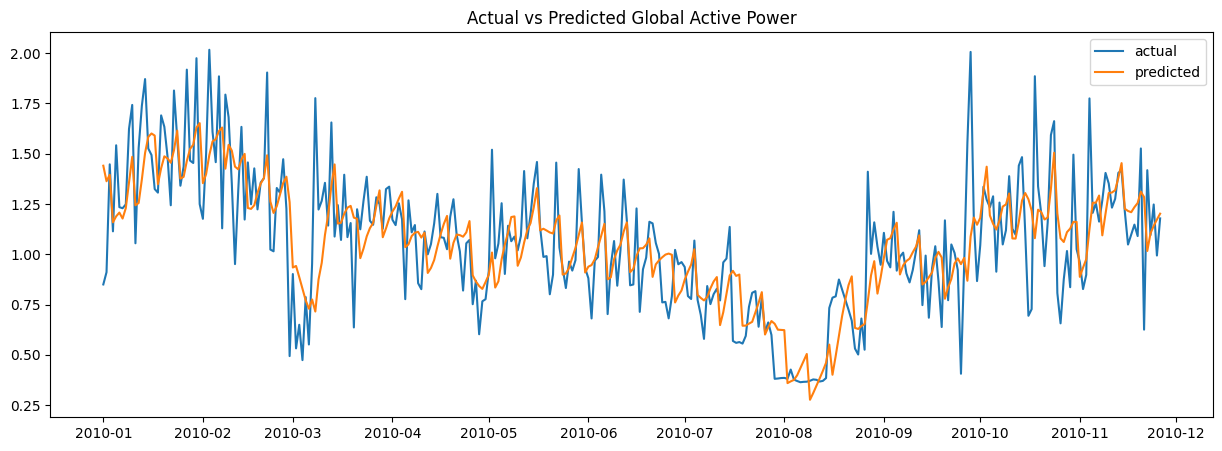

In [ ]:
#Linear regression
from sklearn.linear_model import LinearRegression

model=LinearRegression()

LR_model=model.fit(x_train,y_train)
y_pred =LR_model.predict(x_test) #return numpy array so no index


plt.figure(figsize=(15,5))
plt.plot(y_test.index,y_test,label='actual')
plt.plot(y_test.index,y_pred,label='predicted')

plt.legend()
plt.title("Actual vs Predicted Global Active Power")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred) #Measures how much variance model explains. closer to 1 better

print("mae:",mae) #On average, predictions are off by about 0.167 units
print("rmse:",rmse)#RMSE punishes large mistakes more heavily. Because: RMSE > MAE it means:
                  #some larger forecasting errors/spikes exist.
print("r2:",r2)

mae: 0.1674238462602973
rmse: 0.22973132673379773
r2: 0.5573465714023124


mae: 0.16732529536605792
rmse: 0.2340108779427473
r2: 0.5407010179052562


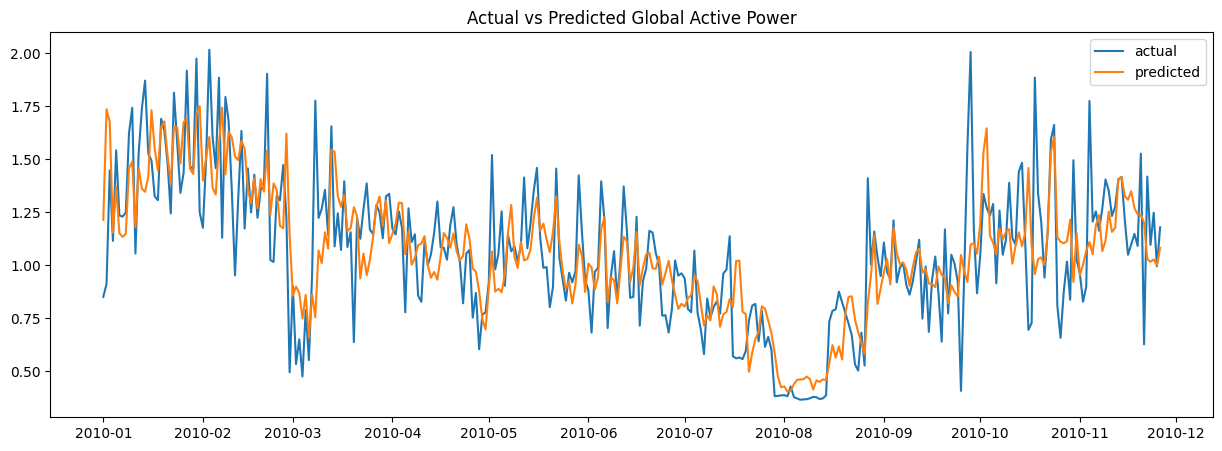

In [ ]:
#Random forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_reg=RandomForestRegressor(n_estimators=100,random_state=42)

rf_model=rf_reg.fit(x_train,y_train)
y_pred=rf_model.predict(x_test)

mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("mae:",mae)
print("rmse:",rmse)
print("r2:",r2)

plt.figure(figsize=(15,5))
plt.plot(y_test.index,y_test,label='actual')
plt.plot(y_test.index,y_pred,label='predicted')

plt.legend()
plt.title("Actual vs Predicted Global Active Power")
plt.show()

XGBoost

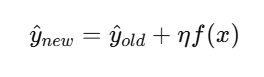

mae: 0.16139518034222455
rmse: 0.22649114411924734
r2: 0.5697450829464965


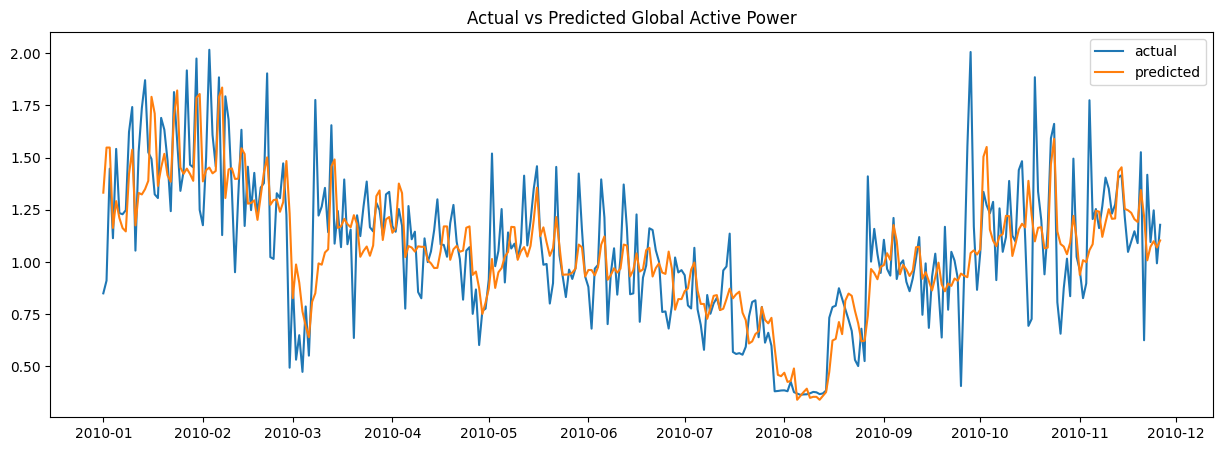

In [ ]:
#XGBoost
#trees built sequentially,
#each correcting previous mistakes

#!pip install XGBoost
from xgboost import XGBRegressor

xgb_reg=XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

xgb_model=xgb_reg.fit(x_train,y_train)
y_pred=xgb_model.predict(x_test)

mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("mae:",mae)
print("rmse:",rmse)
print("r2:",r2)

plt.figure(figsize=(15,5))
plt.plot(y_test.index,y_test,label='actual')
plt.plot(y_test.index,y_pred,label='predicted')

plt.legend()
plt.title("Actual vs Predicted Global Active Power")
plt.show()

In [ ]:
#X=df_daily[["lag_1", "lag_7" ,"rolling_mean_7","rolling_std_7","day_of_week","month"]]

#adding more informative features
df_daily["lag_14"]=df_daily[target].shift(14)
df_daily["lag_30"]=df_daily[target].shift(30)

df_daily["rolling_mean_30"]=df_daily[target].rolling(30).mean()
df_daily["is_weekend"]=(df_daily[target].index.day_of_week > 4).astype(int)

df_daily=df_daily.dropna()
print(df_daily.isnull().sum())


mae: 0.16074438398231466
rmse: 0.2249698532009866
r2: 0.5755055261678231


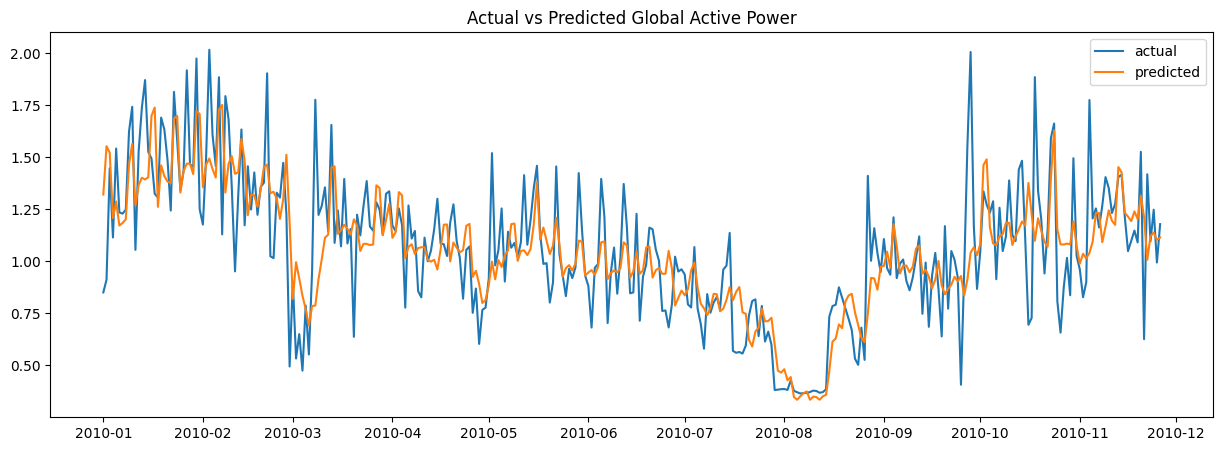

In [ ]:
X=df_daily[["lag_1", "lag_7" ,"rolling_mean_7","rolling_std_7",
            "day_of_week","month","lag_14","lag_30","rolling_mean_30","is_weekend"]]

y=df_daily[target]

#Train test split
x_train=X[:"2009"]
y_train=y[:"2009"]

x_test=X["2010":]
y_test=y["2010":]

xgb_model=xgb_reg.fit(x_train,y_train)
y_pred=xgb_model.predict(x_test)

mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("mae:",mae)
print("rmse:",rmse)
print("r2:",r2)

plt.figure(figsize=(15,5))
plt.plot(y_test.index,y_test,label='actual')
plt.plot(y_test.index,y_pred,label='predicted')

plt.legend()
plt.title("Actual vs Predicted Global Active Power")
plt.show()

mae: 0.16167489023290807
rmse: 0.22527210550830604
r2: 0.5743641232433778


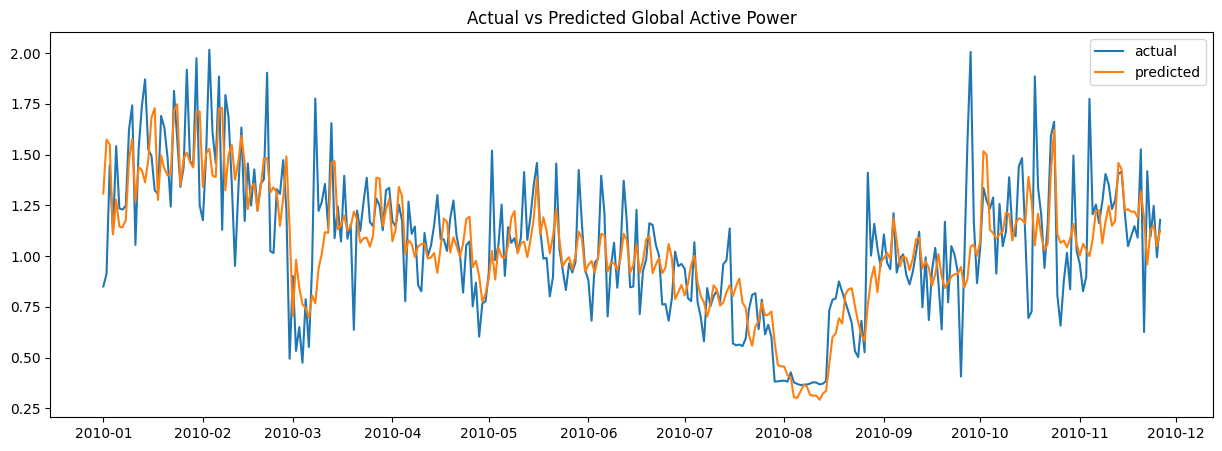

In [ ]:
#try with different parameters

xgb_reg=XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    random_state=42
)

xgb_model=xgb_reg.fit(x_train,y_train)
y_pred=xgb_model.predict(x_test)

mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("mae:",mae)
print("rmse:",rmse)
print("r2:",r2)

plt.figure(figsize=(15,5))
plt.plot(y_test.index,y_test,label='actual')
plt.plot(y_test.index,y_pred,label='predicted')

plt.legend()
plt.title("Actual vs Predicted Global Active Power")
plt.show()

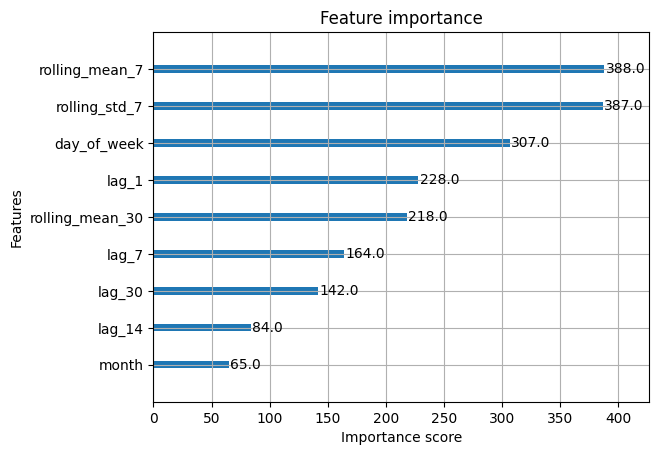

In [ ]:
from xgboost import plot_importance
plot_importance(xgb_model)
plt.show()

In [ ]:
#cross validation

from sklearn.model_selection import TimeSeriesSplit
import numpy as np

X=df_daily[["lag_1", "lag_7" ,"rolling_mean_7","rolling_std_7",
            "day_of_week","month","lag_14","lag_30","rolling_mean_30","is_weekend"]]

y=df_daily[target]

tscv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

mae_scores=[]
rmse_scores=[]
r2_scores=[]

for i,(train_index,test_index) in enumerate(tscv.split(X)):
  #print(f" fold{i}:")
  #print(f"train_index:{train_index}")
  #print(f"test_index:{test_index}")

  #Train test split
  x_train=X.iloc[train_index]
  y_train=y.iloc[train_index]

  x_test=X.iloc[test_index]
  y_test=y.iloc[test_index]

  xgb_model=xgb_reg.fit(x_train,y_train)
  y_pred=xgb_model.predict(x_test)

  mae=mean_absolute_error(y_test,y_pred)
  rmse=root_mean_squared_error(y_test,y_pred)
  r2=r2_score(y_test,y_pred)

  mae_scores.append(mae)
  rmse_scores.append(rmse)
  r2_scores.append(r2)

  print(f"Fold {i+1}")
  print("MAE:", mae)
  print("RMSE:", rmse)
  print("R2:", r2)
  print("-"*30)

print("\nAverage Results")
print("MAE :", np.mean(mae_scores))
print("RMSE:", np.mean(rmse_scores))
print("R2  :", np.mean(r2_scores))



Fold 1
MAE: 0.2503291647677861
RMSE: 0.3182637516953627
R2: 0.26887921257956016
------------------------------
Fold 2
MAE: 0.19941089041072307
RMSE: 0.2655132931211271
R2: 0.5999613471292424
------------------------------
Fold 3
MAE: 0.18018364764273215
RMSE: 0.23908861800410264
R2: 0.6152755073003249
------------------------------
Fold 4
MAE: 0.1653885563278644
RMSE: 0.22528531923436623
R2: 0.5174128945359026
------------------------------
Fold 5
MAE: 0.14358886600001447
RMSE: 0.2023197566112014
R2: 0.5510201581164074
------------------------------

Average Results
MAE : 0.18778022502982403
RMSE: 0.250094147733232
R2  : 0.5105098239322874
